# Week 4 — KPI Analytics and Exploratory Data Analysis

**InGen Dynamics**

This notebook conducts exploratory data analysis (EDA) on the Week 3 synthetic robot performance dataset for Aido Rover, Sentinel Prime AI, and Fari.

The analysis focuses on KPI distributions, correlations, time-series patterns, cross-platform comparisons, and outlier detection. All operational performance records used in this notebook are synthetic and were generated in the Week 3 data pipeline using public proxy benchmarks.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Week 3 simulated dataset

DATA_PATH = Path("W03_Simulated_Dataset.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["month"]
)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (180, 17)


,month,platform,unit_id,active_day_engagement_pct,availability_pct,energy_kwh_per_hour,false_alert_pct,goal_success_pct,incident_detection_pct,interactions_per_active_user_day,monitoring_coverage_pct,operator_response_min,patrol_coverage_pct,response_latency_sec,session_duration_min,uptime_pct,data_origin
0,2025-01-01,Aido Rover,AR-01,NaN,NaN,0.223018,2.597403,NaN,82.417582,NaN,NaN,NaN,93.179438,NaN,NaN,96.187708,SYNTHETIC
1,2025-01-01,Aido Rover,AR-02,NaN,NaN,0.197169,1.724138,NaN,85.074627,NaN,NaN,NaN,94.795528,NaN,NaN,94.134543,SYNTHETIC
2,2025-01-01,Aido Rover,AR-03,NaN,NaN,0.128541,0.000000,NaN,93.684211,NaN,NaN,NaN,88.243202,NaN,NaN,94.326833,SYNTHETIC
3,2025-01-01,Aido Rover,AR-04,NaN,NaN,0.224020,3.896104,NaN,98.666667,NaN,NaN,NaN,89.223825,NaN,NaN,99.894718,SYNTHETIC
4,2025-01-01,Aido Rover,AR-05,NaN,NaN,0.240853,5.405405,NaN,86.419753,NaN,NaN,NaN,93.154825,NaN,NaN,96.316179,SYNTHETIC


In [3]:
# Basic dataset structure

print("Platforms:")
print(df["platform"].value_counts())

print("\nDate range:")
print(df["month"].min(), "to", df["month"].max())

print("\nUnique months:")
print(df["month"].nunique())

print("\nUnique units by platform:")
print(df.groupby("platform")["unit_id"].nunique())

print("\nData origin:")
print(df["data_origin"].value_counts())

Platforms:
platform
Aido Rover           60
Fari                 60
Sentinel Prime AI    60
Name: count, dtype: int64

Date range:
2025-01-01 00:00:00 to 2025-12-01 00:00:00

Unique months:
12

Unique units by platform:
platform
Aido Rover           5
Fari                 5
Sentinel Prime AI    5
Name: unit_id, dtype: int64

Data origin:
data_origin
SYNTHETIC    180
Name: count, dtype: int64


## 1. Data Quality and Completeness Check

Before conducting exploratory analysis, the dataset is checked for duplicate monthly records, missing values, platform coverage, and completeness across the 12-month simulation period.

In [4]:
# Check column structure

print("Columns:")
for col in df.columns:
    print("-", col)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Columns:
- month
- platform
- unit_id
- active_day_engagement_pct
- availability_pct
- energy_kwh_per_hour
- false_alert_pct
- goal_success_pct
- incident_detection_pct
- interactions_per_active_user_day
- monitoring_coverage_pct
- operator_response_min
- patrol_coverage_pct
- response_latency_sec
- session_duration_min
- uptime_pct
- data_origin

Data types:


,dtype
month,datetime64[us]
platform,str
unit_id,str
active_day_engagement_pct,float64
availability_pct,float64
energy_kwh_per_hour,float64
false_alert_pct,float64
goal_success_pct,float64
incident_detection_pct,float64
interactions_per_active_user_day,float64


In [5]:
# Check duplicate monthly records

duplicate_count = df.duplicated(
    subset=["platform", "unit_id", "month"]
).sum()

print("Duplicate platform-unit-month records:", duplicate_count)

Duplicate platform-unit-month records: 0


In [6]:
# Check missing values

missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

display(missing_summary)

,missing_count,missing_pct
month,0,0.00
platform,0,0.00
unit_id,0,0.00
active_day_engagement_pct,120,66.67
availability_pct,120,66.67
energy_kwh_per_hour,120,66.67
false_alert_pct,60,33.33
goal_success_pct,120,66.67
incident_detection_pct,60,33.33
interactions_per_active_user_day,120,66.67


In [7]:
# Check monthly coverage by platform

monthly_coverage = (
    df.groupby(["platform", "month"])
      .size()
      .reset_index(name="record_count")
)

display(monthly_coverage)

print(
    "\nAll platform-month combinations contain 5 unit records:",
    (monthly_coverage["record_count"] == 5).all()
)

,platform,month,record_count
0,Aido Rover,2025-01-01,5
1,Aido Rover,2025-02-01,5
2,Aido Rover,2025-03-01,5
3,Aido Rover,2025-04-01,5
4,Aido Rover,2025-05-01,5
5,Aido Rover,2025-06-01,5
6,Aido Rover,2025-07-01,5
7,Aido Rover,2025-08-01,5
8,Aido Rover,2025-09-01,5
9,Aido Rover,2025-10-01,5



All platform-month combinations contain 5 unit records: True


### Structural Missingness

The missing values in the KPI columns are expected because the dataset combines three platforms with different operational metrics. A missing KPI value indicates that the metric is not applicable to that platform rather than an incomplete observation. These structural missing values are therefore retained and are not imputed.

In [8]:
# Verify KPI availability by platform

kpi_columns = [
    "patrol_coverage_pct",
    "incident_detection_pct",
    "false_alert_pct",
    "uptime_pct",
    "energy_kwh_per_hour",
    "monitoring_coverage_pct",
    "operator_response_min",
    "availability_pct",
    "session_duration_min",
    "interactions_per_active_user_day",
    "active_day_engagement_pct",
    "response_latency_sec",
    "goal_success_pct"
]

kpi_availability = (
    df.groupby("platform")[kpi_columns]
      .count()
      .T
)

display(kpi_availability)

platform,Aido Rover,Fari,Sentinel Prime AI
patrol_coverage_pct,60,0,0
incident_detection_pct,60,0,60
false_alert_pct,60,0,60
uptime_pct,60,0,0
energy_kwh_per_hour,60,0,0
monitoring_coverage_pct,0,0,60
operator_response_min,0,0,60
availability_pct,0,0,60
session_duration_min,0,60,0
interactions_per_active_user_day,0,60,0


## 2. Primary KPI Selection

One primary KPI is selected for each platform to support the Week 4 exploratory analysis and dashboard design:

- **Aido Rover:** Patrol Coverage Rate (`patrol_coverage_pct`)
- **Sentinel Prime AI:** Incident Detection Rate (`incident_detection_pct`)
- **Fari:** Active-Day Engagement Rate (`active_day_engagement_pct`)

These metrics represent the main operational outcome for each platform and will receive greater visual emphasis in the Week 4 analysis.

In [9]:
# Define primary KPI for each platform

primary_kpis = {
    "Aido Rover": "patrol_coverage_pct",
    "Sentinel Prime AI": "incident_detection_pct",
    "Fari": "active_day_engagement_pct"
}

primary_kpis

{'Aido Rover': 'patrol_coverage_pct',
 'Sentinel Prime AI': 'incident_detection_pct',
 'Fari': 'active_day_engagement_pct'}

In [10]:
# Summary statistics for primary KPIs

summary_rows = []

for platform, kpi in primary_kpis.items():
    values = df.loc[df["platform"] == platform, kpi].dropna()

    summary_rows.append({
        "platform": platform,
        "primary_kpi": kpi,
        "count": values.count(),
        "mean": values.mean(),
        "std": values.std(),
        "min": values.min(),
        "25%": values.quantile(0.25),
        "median": values.median(),
        "75%": values.quantile(0.75),
        "max": values.max()
    })

primary_kpi_summary = pd.DataFrame(summary_rows)

display(
    primary_kpi_summary.round(2)
)

,platform,primary_kpi,count,mean,std,min,25%,median,75%,max
0,Aido Rover,patrol_coverage_pct,60,93.32,3.43,88.16,90.06,92.96,96.52,99.27
1,Sentinel Prime AI,incident_detection_pct,60,92.49,4.35,80.28,89.07,92.96,95.91,100.00
2,Fari,active_day_engagement_pct,60,77.03,12.41,55.79,66.58,77.47,88.43,96.47


In [11]:
# Monthly averages for the primary KPIs

monthly_primary = []

for platform, kpi in primary_kpis.items():
    temp = (
        df.loc[df["platform"] == platform]
          .groupby("month", as_index=False)[kpi]
          .mean()
    )

    temp["platform"] = platform
    temp["primary_kpi"] = kpi
    temp = temp.rename(columns={kpi: "kpi_value"})

    monthly_primary.append(temp)

monthly_primary = pd.concat(
    monthly_primary,
    ignore_index=True
)

display(monthly_primary.head(15))

,month,kpi_value,platform,primary_kpi
0,2025-01-01,91.719364,Aido Rover,patrol_coverage_pct
1,2025-02-01,93.405733,Aido Rover,patrol_coverage_pct
2,2025-03-01,95.247345,Aido Rover,patrol_coverage_pct
3,2025-04-01,94.052550,Aido Rover,patrol_coverage_pct
4,2025-05-01,93.281391,Aido Rover,patrol_coverage_pct
5,2025-06-01,92.922831,Aido Rover,patrol_coverage_pct
6,2025-07-01,93.967386,Aido Rover,patrol_coverage_pct
7,2025-08-01,92.780897,Aido Rover,patrol_coverage_pct
8,2025-09-01,92.420603,Aido Rover,patrol_coverage_pct
9,2025-10-01,95.118877,Aido Rover,patrol_coverage_pct


## 3. Distribution Analysis of Primary KPIs

The following visualizations examine the distributions of the primary KPI for each platform using the Week 3 synthetic dataset.

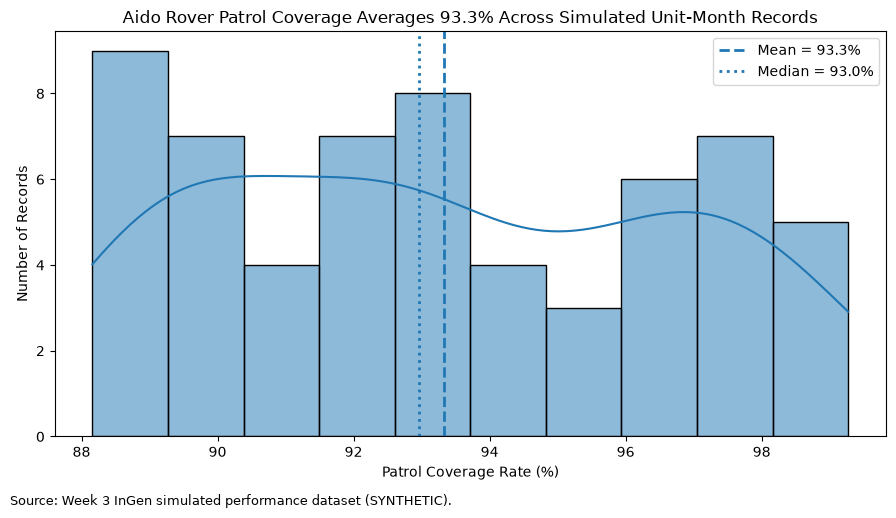

In [12]:
# Distribution of Aido Rover patrol coverage

aido_patrol = df.loc[
    df["platform"] == "Aido Rover",
    "patrol_coverage_pct"
].dropna()

mean_value = aido_patrol.mean()
median_value = aido_patrol.median()

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    aido_patrol,
    bins=10,
    kde=True,
    ax=ax
)

ax.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.1f}%"
)

ax.axvline(
    median_value,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_value:.1f}%"
)

ax.set_title(
    f"Aido Rover Patrol Coverage Averages {mean_value:.1f}% "
    "Across Simulated Unit-Month Records"
)

ax.set_xlabel("Patrol Coverage Rate (%)")
ax.set_ylabel("Number of Records")

ax.legend()

fig.text(
    0.01,
    -0.02,
    "Source: Week 3 InGen simulated performance dataset (SYNTHETIC).",
    fontsize=9
)

plt.tight_layout()
plt.show()

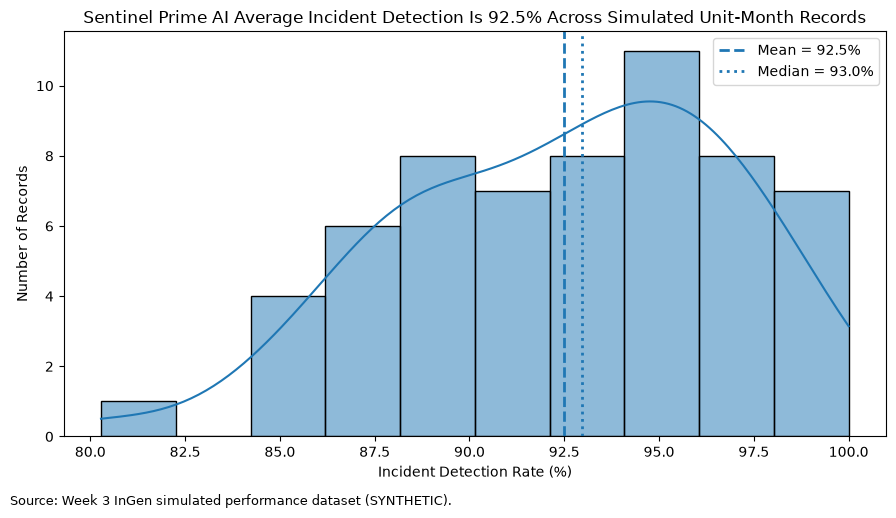

In [13]:
# Distribution of Sentinel Prime AI incident detection rate

sentinel_detection = df.loc[
    df["platform"] == "Sentinel Prime AI",
    "incident_detection_pct"
].dropna()

mean_value = sentinel_detection.mean()
median_value = sentinel_detection.median()

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    sentinel_detection,
    bins=10,
    kde=True,
    ax=ax
)

ax.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.1f}%"
)

ax.axvline(
    median_value,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_value:.1f}%"
)

ax.set_title(
    f"Sentinel Prime AI Average Incident Detection Is {mean_value:.1f}% "
    "Across Simulated Unit-Month Records"
)

ax.set_xlabel("Incident Detection Rate (%)")
ax.set_ylabel("Number of Records")

ax.legend()

fig.text(
    0.01,
    -0.02,
    "Source: Week 3 InGen simulated performance dataset (SYNTHETIC).",
    fontsize=9
)

plt.tight_layout()
plt.show()

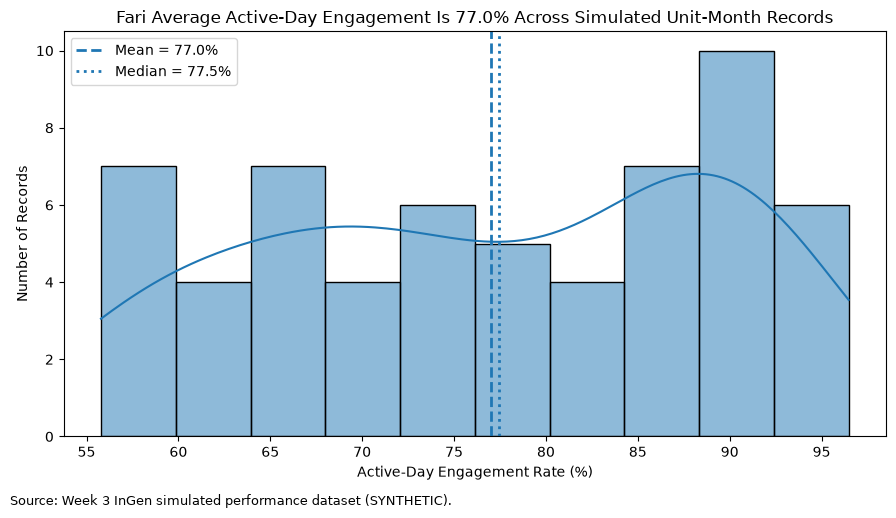

In [14]:
# Distribution of Fari active-day engagement rate

fari_engagement = df.loc[
    df["platform"] == "Fari",
    "active_day_engagement_pct"
].dropna()

mean_value = fari_engagement.mean()
median_value = fari_engagement.median()

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    fari_engagement,
    bins=10,
    kde=True,
    ax=ax
)

ax.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.1f}%"
)

ax.axvline(
    median_value,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_value:.1f}%"
)

ax.set_title(
    f"Fari Average Active-Day Engagement Is {mean_value:.1f}% "
    "Across Simulated Unit-Month Records"
)

ax.set_xlabel("Active-Day Engagement Rate (%)")
ax.set_ylabel("Number of Records")

ax.legend()

fig.text(
    0.01,
    -0.02,
    "Source: Week 3 InGen simulated performance dataset (SYNTHETIC).",
    fontsize=9
)

plt.tight_layout()
plt.show()

## 4. KPI Correlation Analysis

The correlation analysis evaluates relationships among KPI variables in the synthetic dataset. Because some KPIs are platform-specific, correlations are calculated only where overlapping observations are available.

In [15]:
# Calculate KPI correlation matrix

kpi_columns = [
    "patrol_coverage_pct",
    "incident_detection_pct",
    "false_alert_pct",
    "uptime_pct",
    "energy_kwh_per_hour",
    "monitoring_coverage_pct",
    "operator_response_min",
    "availability_pct",
    "session_duration_min",
    "interactions_per_active_user_day",
    "active_day_engagement_pct",
    "response_latency_sec",
    "goal_success_pct"
]

correlation_matrix = df[kpi_columns].corr()

display(correlation_matrix.round(2))

,patrol_coverage_pct,incident_detection_pct,false_alert_pct,uptime_pct,energy_kwh_per_hour,monitoring_coverage_pct,operator_response_min,availability_pct,session_duration_min,interactions_per_active_user_day,active_day_engagement_pct,response_latency_sec,goal_success_pct
patrol_coverage_pct,1.00,-0.07,-0.02,-0.08,-0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_detection_pct,-0.07,1.00,-0.18,0.06,-0.17,-0.07,-0.12,-0.11,NaN,NaN,NaN,NaN,NaN
false_alert_pct,-0.02,-0.18,1.00,0.28,-0.21,-0.11,0.22,0.12,NaN,NaN,NaN,NaN,NaN
uptime_pct,-0.08,0.06,0.28,1.00,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy_kwh_per_hour,-0.01,-0.17,-0.21,0.02,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monitoring_coverage_pct,NaN,-0.07,-0.11,NaN,NaN,1.00,-0.20,0.01,NaN,NaN,NaN,NaN,NaN
operator_response_min,NaN,-0.12,0.22,NaN,NaN,-0.20,1.00,0.27,NaN,NaN,NaN,NaN,NaN
availability_pct,NaN,-0.11,0.12,NaN,NaN,0.01,0.27,1.00,NaN,NaN,NaN,NaN,NaN
session_duration_min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,-0.19,0.01,0.19,0.24
interactions_per_active_user_day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.19,1.00,0.01,-0.00,0.05


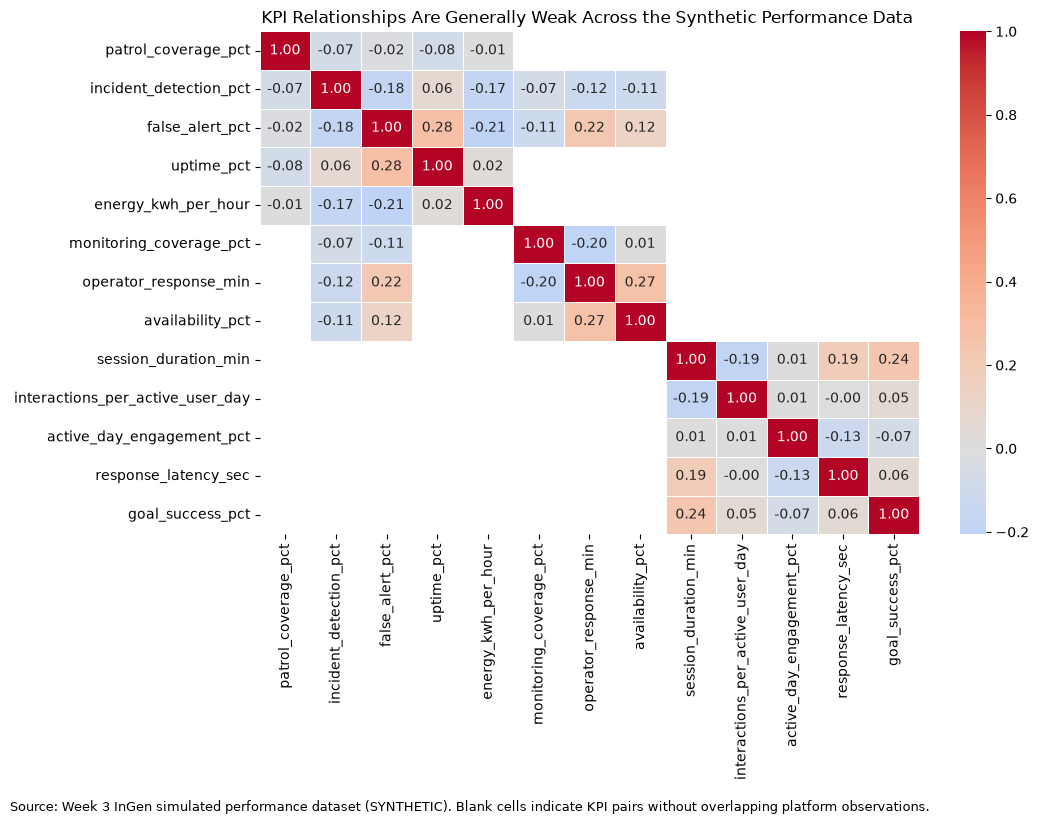

In [16]:
# Correlation heatmap for KPI variables

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "KPI Relationships Are Generally Weak Across the Synthetic Performance Data "
)

fig.text(
    0.01,
    -0.02,
    "Source: Week 3 InGen simulated performance dataset (SYNTHETIC). "
    "Blank cells indicate KPI pairs without overlapping platform observations.",
    fontsize=9
)

plt.tight_layout()
plt.show()

### Correlation Interpretation

The synthetic dataset shows generally weak relationships among the KPI variables, with no off-diagonal correlation exceeding approximately 0.30 in absolute value.

Some relationships are directionally plausible. For example, Sentinel Prime AI monitoring coverage has a weak negative correlation with operator response time, suggesting that broader monitoring coverage may coincide with slightly faster response in the simulated records. Fari session duration also has a weak positive relationship with goal-oriented interaction success.

However, these correlations are small and are based on synthetic data. They should therefore be interpreted as exploratory patterns rather than evidence of causal operational relationships. Blank cells represent KPI pairs that do not have overlapping observations because the metrics belong to different platforms.

## 5. Time-Series Analysis

The following charts examine monthly changes in the primary KPI for selected platforms across the 12-month simulation period.

Highest month: May 95.2%
Lowest month: June 90.4%


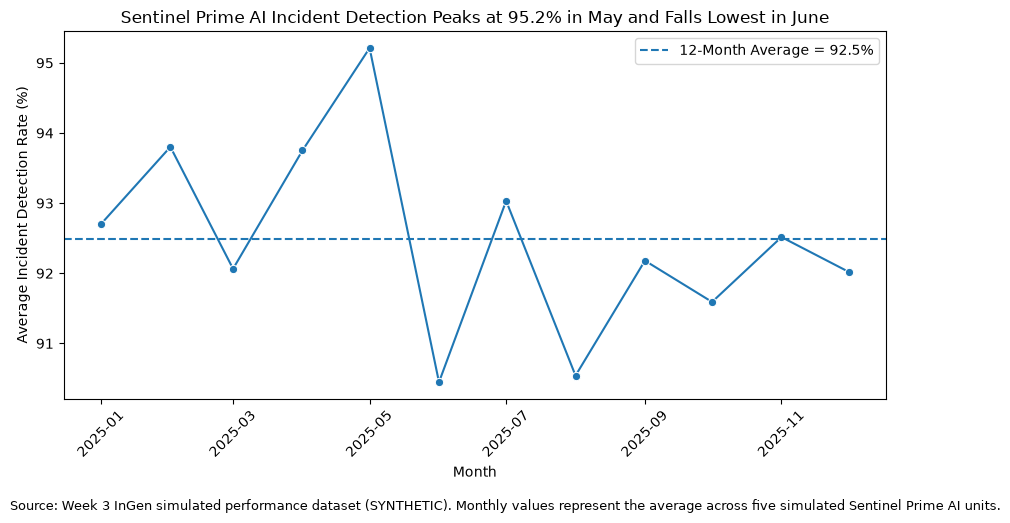

In [17]:
# Sentinel Prime AI monthly incident detection trend

sentinel_monthly = monthly_primary[
    monthly_primary["platform"] == "Sentinel Prime AI"
].copy()

# Identify highest and lowest months
sentinel_peak = sentinel_monthly.loc[
    sentinel_monthly["kpi_value"].idxmax()
]

sentinel_low = sentinel_monthly.loc[
    sentinel_monthly["kpi_value"].idxmin()
]

print(
    "Highest month:",
    sentinel_peak["month"].strftime("%B"),
    f"{sentinel_peak['kpi_value']:.1f}%"
)

print(
    "Lowest month:",
    sentinel_low["month"].strftime("%B"),
    f"{sentinel_low['kpi_value']:.1f}%"
)

# Plot monthly trend
fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=sentinel_monthly,
    x="month",
    y="kpi_value",
    marker="o",
    ax=ax
)

ax.axhline(
    sentinel_monthly["kpi_value"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"12-Month Average = {sentinel_monthly['kpi_value'].mean():.1f}%"
)

ax.set_title(
    f"Sentinel Prime AI Incident Detection Peaks at "
    f"{sentinel_peak['kpi_value']:.1f}% in "
    f"{sentinel_peak['month'].strftime('%B')} and Falls Lowest in "
    f"{sentinel_low['month'].strftime('%B')}"
)

ax.set_xlabel("Month")
ax.set_ylabel("Average Incident Detection Rate (%)")

ax.tick_params(
    axis="x",
    rotation=45
)

ax.legend()

fig.text(
    0.01,
    -0.03,
    "Source: Week 3 InGen simulated performance dataset (SYNTHETIC). "
    "Monthly values represent the average across five simulated Sentinel Prime AI units.",
    fontsize=9
)

plt.tight_layout()
plt.show()

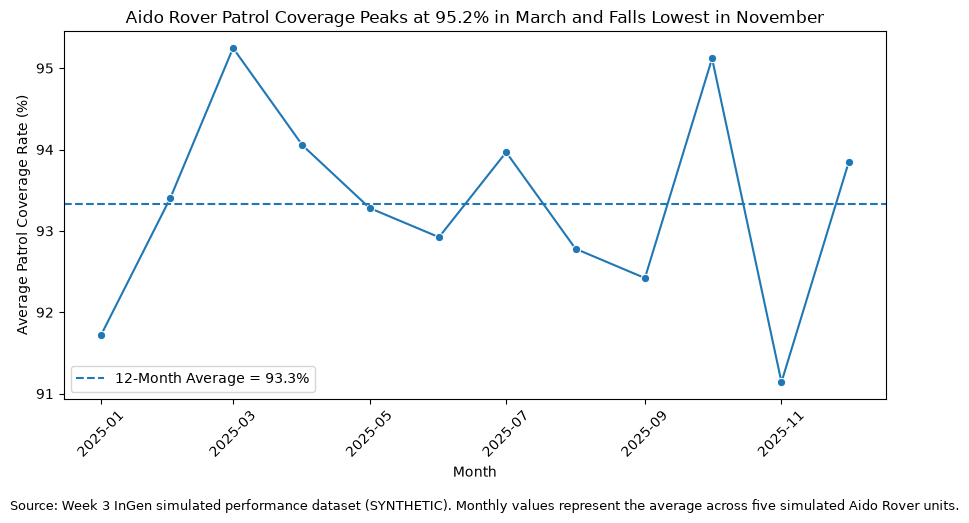

In [18]:
# Aido Rover monthly patrol coverage trend

aido_monthly = monthly_primary[
    monthly_primary["platform"] == "Aido Rover"
].copy()

aido_peak = aido_monthly.loc[
    aido_monthly["kpi_value"].idxmax()
]

aido_low = aido_monthly.loc[
    aido_monthly["kpi_value"].idxmin()
]

fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=aido_monthly,
    x="month",
    y="kpi_value",
    marker="o",
    ax=ax
)

ax.axhline(
    aido_monthly["kpi_value"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"12-Month Average = {aido_monthly['kpi_value'].mean():.1f}%"
)

ax.set_title(
    f"Aido Rover Patrol Coverage Peaks at "
    f"{aido_peak['kpi_value']:.1f}% in "
    f"{aido_peak['month'].strftime('%B')} and Falls Lowest in "
    f"{aido_low['month'].strftime('%B')}"
)

ax.set_xlabel("Month")
ax.set_ylabel("Average Patrol Coverage Rate (%)")

ax.tick_params(axis="x", rotation=45)
ax.legend()

fig.text(
    0.01,
    -0.03,
    "Source: Week 3 InGen simulated performance dataset (SYNTHETIC). "
    "Monthly values represent the average across five simulated Aido Rover units.",
    fontsize=9
)

plt.tight_layout()
plt.show()

## 6. Cross-Platform Comparison

Because Aido Rover and Sentinel Prime AI share the incident detection KPI, their simulated distributions can be compared directly using the same measurement definition.

In [19]:
# Compare incident detection rates across Aido Rover and Sentinel Prime AI

incident_comparison = df[
    df["platform"].isin(
        ["Aido Rover", "Sentinel Prime AI"]
    )
][
    ["platform", "incident_detection_pct"]
].dropna()

comparison_means = (
    incident_comparison
    .groupby("platform")["incident_detection_pct"]
    .mean()
)

display(comparison_means.round(2))

platform
Aido Rover           93.08
Sentinel Prime AI    92.49
Name: incident_detection_pct, dtype: float64

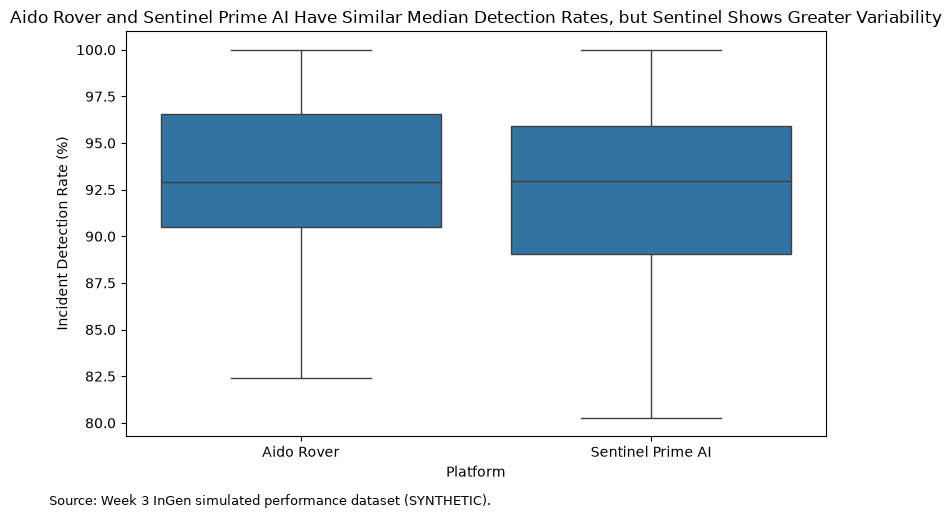

In [20]:
# Cross-platform comparison of incident detection rate

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=incident_comparison,
    x="platform",
    y="incident_detection_pct",
    ax=ax
)

ax.set_title(
    "Aido Rover and Sentinel Prime AI Have Similar Median Detection Rates, "
    "but Sentinel Shows Greater Variability"
)

ax.set_xlabel("Platform")
ax.set_ylabel("Incident Detection Rate (%)")

fig.text(
    0.01,
    -0.02,
    "Source: Week 3 InGen simulated performance dataset (SYNTHETIC).",
    fontsize=9
)

plt.tight_layout()
plt.show()

## 7. Outlier Analysis

Potential KPI outliers are identified using the 1.5 × IQR rule. This analysis focuses on the primary KPI for each platform and determines whether any simulated unit-month records fall outside the expected distribution range.

In [21]:
# Identify outliers in each platform's primary KPI using the 1.5 × IQR rule

outlier_results = []

for platform, kpi in primary_kpis.items():

    values = df.loc[
        df["platform"] == platform,
        kpi
    ].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = values[
        (values < lower_bound) |
        (values > upper_bound)
    ]

    outlier_results.append({
        "platform": platform,
        "primary_kpi": kpi,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary.round(2))

,platform,primary_kpi,q1,q3,iqr,lower_bound,upper_bound,outlier_count
0,Aido Rover,patrol_coverage_pct,90.06,96.52,6.45,80.38,106.20,0
1,Sentinel Prime AI,incident_detection_pct,89.07,95.91,6.84,78.80,106.18,0
2,Fari,active_day_engagement_pct,66.58,88.43,21.85,33.81,121.20,0


In [22]:
# Prepare primary KPI values for outlier visualization

primary_outlier_data = []

for platform, kpi in primary_kpis.items():
    temp = df.loc[
        df["platform"] == platform,
        ["platform", kpi]
    ].dropna().copy()

    temp = temp.rename(columns={kpi: "primary_kpi_value"})
    temp["primary_kpi"] = kpi

    primary_outlier_data.append(temp)

primary_outlier_data = pd.concat(
    primary_outlier_data,
    ignore_index=True
)

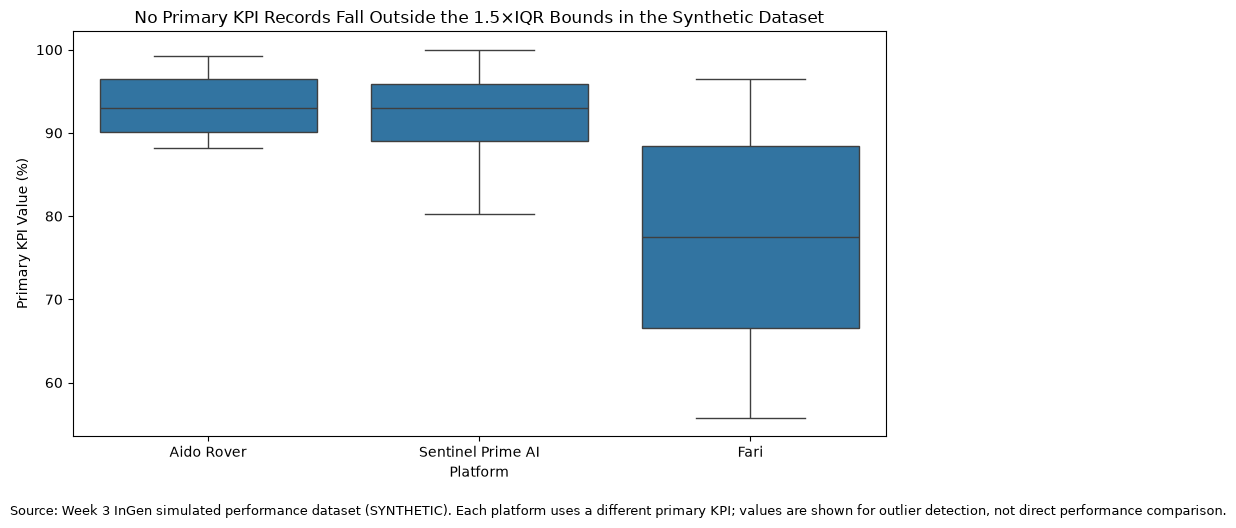

In [23]:
# Visualize primary KPI distributions for IQR outlier analysis

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=primary_outlier_data,
    x="platform",
    y="primary_kpi_value",
    ax=ax
)

ax.set_title(
    "No Primary KPI Records Fall Outside the 1.5×IQR Bounds "
    "in the Synthetic Dataset"
)

ax.set_xlabel("Platform")
ax.set_ylabel("Primary KPI Value (%)")

fig.text(
    0.01,
    -0.04,
    "Source: Week 3 InGen simulated performance dataset (SYNTHETIC). "
    "Each platform uses a different primary KPI; values are shown for outlier detection, "
    "not direct performance comparison.",
    fontsize=9
)

plt.tight_layout()
plt.show()

## 8. Tableau Data Preparation

The Week 3 dataset stores platform-specific KPIs in separate columns. For the Tableau dashboard, the data is reshaped into a long format so that platform, KPI, KPI category, and time-period filters can be applied consistently.

In [24]:
# Define the 15 platform-specific KPIs for Tableau

kpi_map = {
    "Aido Rover": {
        "patrol_coverage_pct": (
            "Patrol Coverage Rate",
            "Coverage"
        ),
        "incident_detection_pct": (
            "Incident Detection Rate",
            "Detection"
        ),
        "false_alert_pct": (
            "False Alarm Rate",
            "Alert Quality"
        ),
        "uptime_pct": (
            "Uptime Percentage",
            "Reliability"
        ),
        "energy_kwh_per_hour": (
            "Energy Consumption per Patrol Hour",
            "Efficiency"
        )
    },

    "Sentinel Prime AI": {
        "incident_detection_pct": (
            "Incident Detection Rate",
            "Detection"
        ),
        "false_alert_pct": (
            "False Positive Rate",
            "Alert Quality"
        ),
        "operator_response_min": (
            "Mean Operator Response Time",
            "Response"
        ),
        "monitoring_coverage_pct": (
            "Coverage Area Rate",
            "Coverage"
        ),
        "availability_pct": (
            "System Availability",
            "Reliability"
        )
    },

    "Fari": {
        "session_duration_min": (
            "Average Session Duration",
            "Engagement"
        ),
        "interactions_per_active_user_day": (
            "Interaction Frequency",
            "Engagement"
        ),
        "active_day_engagement_pct": (
            "Active-Day Engagement Rate",
            "Engagement"
        ),
        "response_latency_sec": (
            "Average Response Time",
            "Response"
        ),
        "goal_success_pct": (
            "Goal-Oriented Interaction Success Rate",
            "Success"
        )
    }
}

In [25]:
# Reshape the Week 3 dataset into Tableau-friendly long format

tableau_rows = []

for platform, platform_kpis in kpi_map.items():

    platform_df = df[
        df["platform"] == platform
    ]

    for kpi_column, (kpi_name, kpi_category) in platform_kpis.items():

        temp = platform_df[
            [
                "month",
                "platform",
                "unit_id",
                "data_origin",
                kpi_column
            ]
        ].copy()

        temp = temp.rename(
            columns={
                kpi_column: "kpi_value"
            }
        )

        temp["kpi_name"] = kpi_name
        temp["kpi_category"] = kpi_category
        temp["kpi_field"] = kpi_column

        tableau_rows.append(temp)

tableau_data = pd.concat(
    tableau_rows,
    ignore_index=True
)

tableau_data = tableau_data[
    [
        "month",
        "platform",
        "unit_id",
        "kpi_name",
        "kpi_category",
        "kpi_field",
        "kpi_value",
        "data_origin"
    ]
]

display(tableau_data.head(10))

,month,platform,unit_id,kpi_name,kpi_category,kpi_field,kpi_value,data_origin
0,2025-01-01,Aido Rover,AR-01,Patrol Coverage Rate,Coverage,patrol_coverage_pct,93.179438,SYNTHETIC
1,2025-01-01,Aido Rover,AR-02,Patrol Coverage Rate,Coverage,patrol_coverage_pct,94.795528,SYNTHETIC
2,2025-01-01,Aido Rover,AR-03,Patrol Coverage Rate,Coverage,patrol_coverage_pct,88.243202,SYNTHETIC
3,2025-01-01,Aido Rover,AR-04,Patrol Coverage Rate,Coverage,patrol_coverage_pct,89.223825,SYNTHETIC
4,2025-01-01,Aido Rover,AR-05,Patrol Coverage Rate,Coverage,patrol_coverage_pct,93.154825,SYNTHETIC
5,2025-02-01,Aido Rover,AR-01,Patrol Coverage Rate,Coverage,patrol_coverage_pct,97.517758,SYNTHETIC
6,2025-02-01,Aido Rover,AR-02,Patrol Coverage Rate,Coverage,patrol_coverage_pct,91.813043,SYNTHETIC
7,2025-02-01,Aido Rover,AR-03,Patrol Coverage Rate,Coverage,patrol_coverage_pct,90.087232,SYNTHETIC
8,2025-02-01,Aido Rover,AR-04,Patrol Coverage Rate,Coverage,patrol_coverage_pct,96.932831,SYNTHETIC
9,2025-02-01,Aido Rover,AR-05,Patrol Coverage Rate,Coverage,patrol_coverage_pct,90.677801,SYNTHETIC


In [26]:
print("Tableau dataset shape:", tableau_data.shape)

print("\nRecords by platform:")
print(
    tableau_data["platform"].value_counts()
)

print("\nUnique KPIs by platform:")
print(
    tableau_data.groupby("platform")["kpi_name"].nunique()
)

print("\nTotal platform-KPI combinations:")
print(
    tableau_data[
        ["platform", "kpi_name"]
    ].drop_duplicates().shape[0]
)

print("\nMissing KPI values:")
print(
    tableau_data["kpi_value"].isna().sum()
)

Tableau dataset shape: (900, 8)

Records by platform:
platform
Aido Rover           300
Sentinel Prime AI    300
Fari                 300
Name: count, dtype: int64

Unique KPIs by platform:
platform
Aido Rover           5
Fari                 5
Sentinel Prime AI    5
Name: kpi_name, dtype: int64

Total platform-KPI combinations:
15

Missing KPI values:
0


In [27]:
# Export Tableau-ready dataset

TABLEAU_OUTPUT_PATH = Path("W04_Tableau_Data.csv")

tableau_data.to_csv(
    TABLEAU_OUTPUT_PATH,
    index=False
)

print("Tableau dataset exported to:")
print(TABLEAU_OUTPUT_PATH.resolve())

print("\nExported rows:", len(tableau_data))

Tableau dataset exported to:
D:\大王只想要工作\intern\Week 4\W04_Tableau_Data.csv

Exported rows: 900


In [28]:
# Verify exported Tableau dataset

tableau_check = pd.read_csv(
    TABLEAU_OUTPUT_PATH,
    parse_dates=["month"]
)

print("Exported dataset shape:", tableau_check.shape)
display(tableau_check.head())

Exported dataset shape: (900, 8)


,month,platform,unit_id,kpi_name,kpi_category,kpi_field,kpi_value,data_origin
0,2025-01-01,Aido Rover,AR-01,Patrol Coverage Rate,Coverage,patrol_coverage_pct,93.179438,SYNTHETIC
1,2025-01-01,Aido Rover,AR-02,Patrol Coverage Rate,Coverage,patrol_coverage_pct,94.795528,SYNTHETIC
2,2025-01-01,Aido Rover,AR-03,Patrol Coverage Rate,Coverage,patrol_coverage_pct,88.243202,SYNTHETIC
3,2025-01-01,Aido Rover,AR-04,Patrol Coverage Rate,Coverage,patrol_coverage_pct,89.223825,SYNTHETIC
4,2025-01-01,Aido Rover,AR-05,Patrol Coverage Rate,Coverage,patrol_coverage_pct,93.154825,SYNTHETIC
